In [1]:
# Cài đặt thư viện (chạy lần đầu tiên)
!pip install timm -q

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import timm
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

print("✅ Đã import tất cả thư viện")
print(f"PyTorch: {torch.__version__} | timm: {timm.__version__}")

✅ Đã import tất cả thư viện
PyTorch: 2.10.0+cu128 | timm: 1.0.26


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

base_dir = '/content/drive/MyDrive/HAM10000'
split_dir = os.path.join(base_dir, 'splits')

print("✅ Đường dẫn data:", base_dir)
print("Split folder:", split_dir)
print("Các file split:", os.listdir(split_dir))

Mounted at /content/drive
✅ Đường dẫn data: /content/drive/MyDrive/HAM10000
Split folder: /content/drive/MyDrive/HAM10000/splits
Các file split: ['train_split.csv', 'test_split.csv', 'val_split.csv']


✅ Train: 7010 | Val: 1502 | Test: 1503
Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


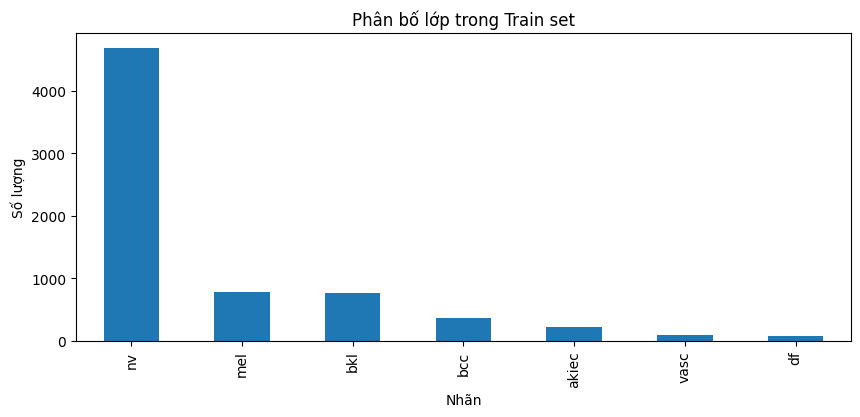

In [3]:
# Load splits
train_df = pd.read_csv(os.path.join(split_dir, 'train_split.csv'))
val_df   = pd.read_csv(os.path.join(split_dir, 'val_split.csv'))
test_df  = pd.read_csv(os.path.join(split_dir, 'test_split.csv'))

# Load class names
class_names = np.load(os.path.join(base_dir, 'class_names.npy'), allow_pickle=True).tolist()

print(f"✅ Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes ({len(class_names)}): {class_names}")

# Kiểm tra class distribution
plt.figure(figsize=(10,4))
train_df['dx'].value_counts().plot(kind='bar')
plt.title('Phân bố lớp trong Train set')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.show()

In [4]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.loc[idx, 'label'])

        if self.transform:
            image = self.transform(image)

        return image, label

print("✅ Đã định nghĩa HAM10000Dataset")

✅ Đã định nghĩa HAM10000Dataset


In [5]:
IMG_SIZE = 224   # Đổi thành 384 nếu dùng convnextv2_large

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

print(f"✅ Transforms sẵn sàng - Input size: {IMG_SIZE}x{IMG_SIZE}")

✅ Transforms sẵn sàng - Input size: 224x224


In [6]:
BATCH_SIZE = 32
NUM_WORKERS = 4

# Tạo dataset
train_dataset = HAM10000Dataset(train_df, transform=train_transform)
val_dataset   = HAM10000Dataset(val_df,   transform=val_transform)
test_dataset  = HAM10000Dataset(test_df,  transform=val_transform)

# WeightedRandomSampler cho train (rất quan trọng với HAM10000 imbalance)
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1. / class_counts
sample_weights = class_weights[train_df['label'].values]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ DataLoader đã tạo (dùng WeightedSampler cho train)")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

✅ DataLoader đã tạo (dùng WeightedSampler cho train)
Train batches: 219 | Val: 47 | Test: 47


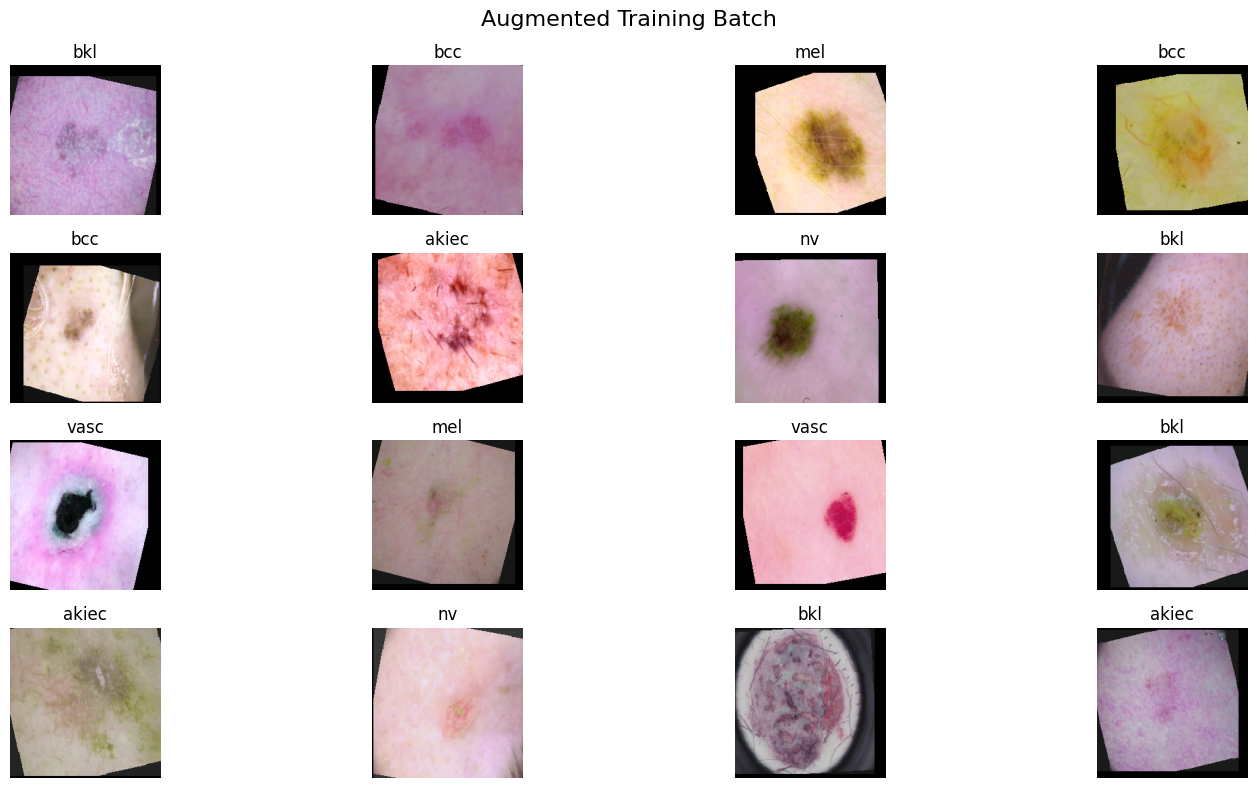

In [7]:
def show_augmented_batch(loader, class_names, num_images=16):
    images, labels = next(iter(loader))
    plt.figure(figsize=(16, 8))
    for i in range(num_images):
        plt.subplot(4, 4, i+1)
        img = images[i].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.suptitle('Augmented Training Batch', fontsize=16)
    plt.tight_layout()
    plt.show()

show_augmented_batch(train_loader, class_names)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

# ConvNeXt V2 Tiny (nhanh, chính xác cao cho HAM10000)
model = timm.create_model('convnextv2_tiny', pretrained=True, num_classes=len(class_names))
model = model.to(device)

# Loss với class weights (tăng thêm hiệu quả)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print("✅ Model ConvNeXt V2 Tiny + Optimizer + Scheduler sẵn sàng")

✅ Device: cuda


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

✅ Model ConvNeXt V2 Tiny + Optimizer + Scheduler sẵn sàng


In [9]:
EPOCHS = 30
best_f1 = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_f1'].append(val_f1)

    scheduler.step()

    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f}")

    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(base_dir, 'best_convnextv2_tiny.pth'))
        print("   → Saved best model!")

print("✅ Hoàn thành training!")

Epoch 1/30: 100%|██████████| 219/219 [04:49<00:00,  1.32s/it]


Epoch  1 | Train Loss: 0.5155 | Val Loss: 0.9569 | Val F1: 0.4053
   → Saved best model!


Epoch 2/30: 100%|██████████| 219/219 [03:04<00:00,  1.19it/s]


Epoch  2 | Train Loss: 0.2071 | Val Loss: 0.7542 | Val F1: 0.5105
   → Saved best model!


Epoch 3/30: 100%|██████████| 219/219 [02:55<00:00,  1.25it/s]


...

Epoch 23 | Train Loss: 0.0057 | Val Loss: 0.6770 | Val F1: 0.7799


Epoch 24/30: 100%|██████████| 219/219 [02:49<00:00,  1.29it/s]


Epoch 24 | Train Loss: 0.0051 | Val Loss: 0.6906 | Val F1: 0.7741


Epoch 25/30:  92%|█████████▏| 202/219 [02:38<00:13,  1.28it/s]


KeyboardInterrupt: 

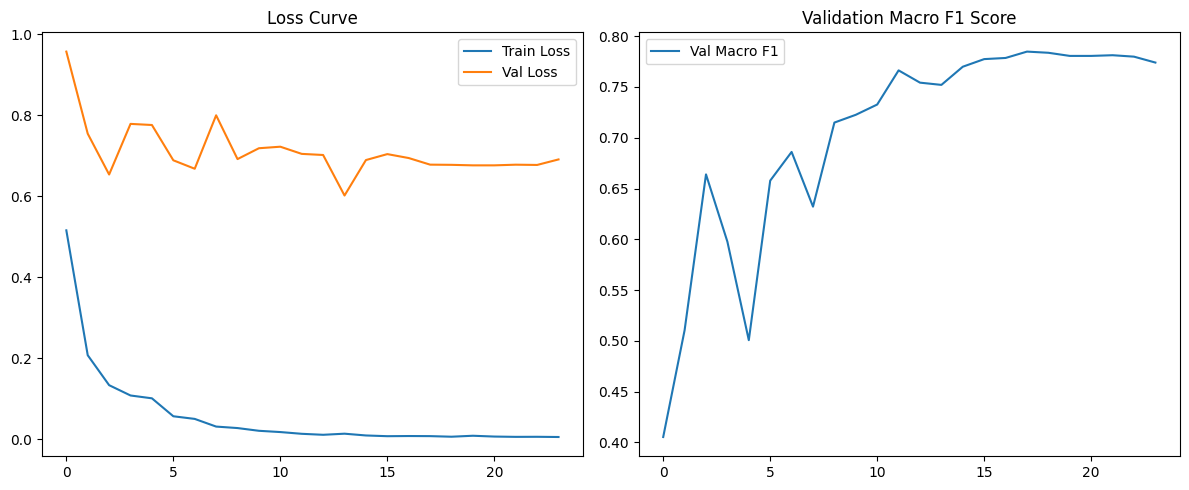

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_f1'], label='Val Macro F1')
plt.title('Validation Macro F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

Evaluating Test set: 100%|██████████| 47/47 [02:13<00:00,  2.84s/it]



FINAL TEST RESULTS
              precision    recall  f1-score   support

       akiec     0.7609    0.7143    0.7368        49
         bcc     0.7204    0.8701    0.7882        77
         bkl     0.7017    0.7697    0.7341       165
          df     0.8125    0.7647    0.7879        17
         mel     0.4634    0.7964    0.5859       167
          nv     0.9673    0.8231    0.8894      1006
        vasc     0.8333    0.9091    0.8696        22

    accuracy                         0.8137      1503
   macro avg     0.7514    0.8068    0.7703      1503
weighted avg     0.8591    0.8137    0.8270      1503



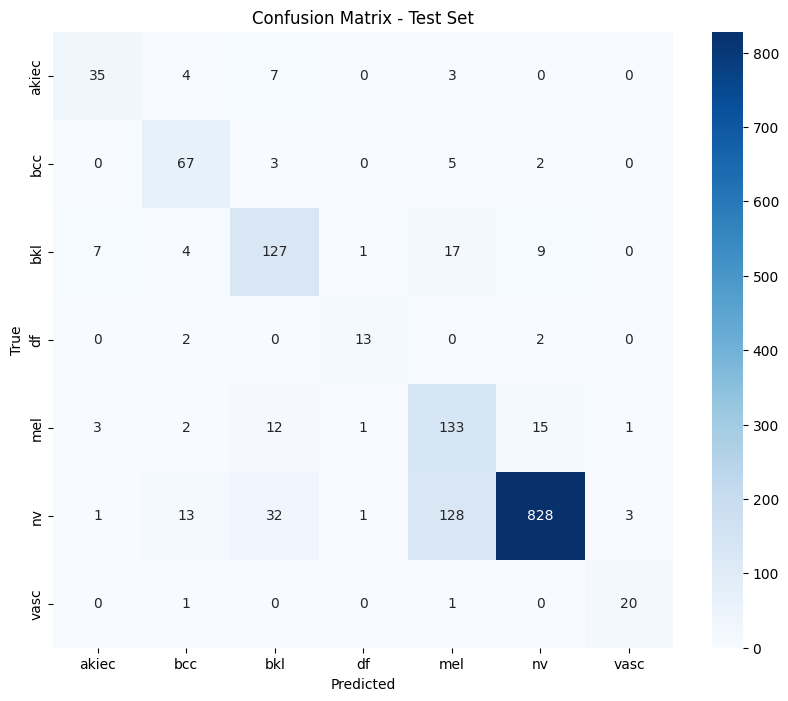

In [11]:
model.load_state_dict(torch.load(os.path.join(base_dir, 'best_convnextv2_tiny.pth')))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating Test set"):
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Report
print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.show()